# 量子传感仿真平台测试 — `sqc` 版本

对标 [`Simulation.ipynb`](Simulation.ipynb)，本 notebook 用重构后的 `sqc.*` API 演示各 sensing protocol。

**主要差异**：
- 顶层 API 从 `src.protocal.Protocal(type=N)` switch-case 改为独立的 `*Experiment` 类（`RabiExperiment`、`RamseyExperiment`、…）。
- 信号重建从 `Analysis.<method>()` 改为独立的 `*Reconstruction` 类。
- 所有时间轴从全局 `sqc.config.CONFIG` 派生（`dt = 1 / sample_rate`），不再用 `np.linspace`。
- 实验返回统一的 `ExperimentResult`（`.data` / `.axes` / `.metadata` / `.config`），便于序列化。

**关于兼容性**：sqc 的 `TransmonQubit` 是 `src.qubit.TransmonQubit` 的现代等价实现，构造签名一致。

## 0. 环境与全局配置

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from sqc.config import CONFIG
from sqc.devices.transmon import TransmonQubit
from sqc.control.flux_signal import FluxSignal

print(f"AWG sample_rate = {CONFIG.awg.sample_rate} GSa/s  →  dt = {CONFIG.awg.dt} ns")
print(f"t_rabi  : start={CONFIG.pulse.t_rabi[0]:.2f}  end={CONFIG.pulse.t_rabi[-1]:.2f}  N={len(CONFIG.pulse.t_rabi)}")
print(f"t_global: start={CONFIG.pulse.t_global[0]:.2f}  end={CONFIG.pulse.t_global[-1]:.2f}  N={len(CONFIG.pulse.t_global)}")
print(f"tau_list: N={len(CONFIG.pulse.tau_list)}")
print(f"Transmon defaults: EC/h={CONFIG.transmon.EC} GHz, EJ/h={CONFIG.transmon.EJ} GHz")

AWG sample_rate = 2.0 GSa/s  →  dt = 0.5 ns
t_rabi  : start=0.00  end=9.50  N=20
t_global: start=-50.00  end=399.50  N=900
tau_list: N=500
Transmon defaults: EC/h=0.2 GHz, EJ/h=15.0 GHz


## 1. Rabi 振荡 — `RabiExperiment`

对应原 `Protocal(type=0)`。施加恒定振幅驱动脉冲，测量 $p_e(t)$。

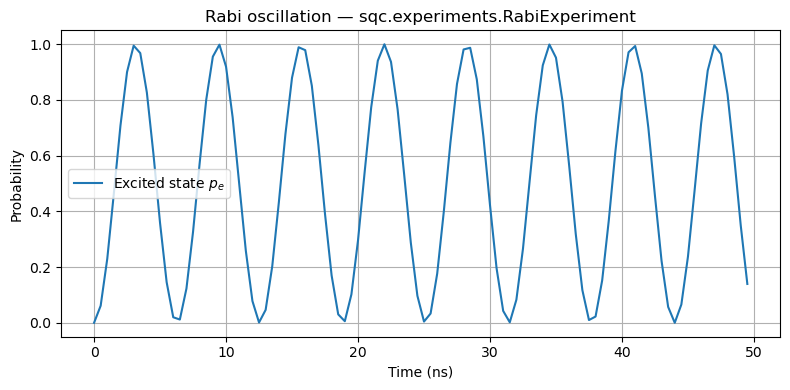

In [2]:
from sqc.experiments.rabi import RabiExperiment

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    state=0,
    n_levels=2,
)

t_rabi = CONFIG.pulse.make_time(0, 50)  # ns
rabi_exp = RabiExperiment(qubit=qubit, t_rabi=t_rabi)
rabi_result = rabi_exp.run()

p_e = rabi_result.expect[0]

plt.figure(figsize=(8, 4))
plt.plot(t_rabi, p_e, label="Excited state $p_e$")
plt.xlabel("Time (ns)")
plt.ylabel("Probability")
plt.title("Rabi oscillation — sqc.experiments.RabiExperiment")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()

## 2. Ramsey 干涉 — `RamseyExperiment` + `RamseyUnwrapReconstruction`

对应原 `Protocal(type=1)`。$\pi/2$ — $\tau$ — $\pi/2$ 序列测自由演化期间积累的相位，由相位演化反推磁场 $B(t)$。

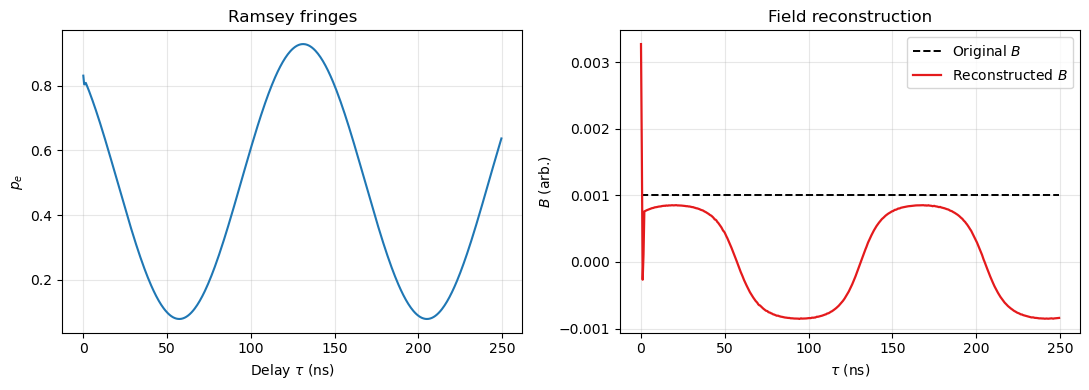

In [4]:
from sqc.experiments.ramsey import RamseyExperiment
from sqc.reconstruction.wiener import RamseyUnwrapReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi,
    EJ=10.0 * 2 * np.pi,
    T1=100.0e3,
    T2=50.0e3,
    flux=0.0,
    state=0,
    n_levels=2,
)
# 移到敏感工作点（dω/dΦ 最大处附近）
Phi_work = qubit._spec.optimal_work_point() if hasattr(qubit._spec, "optimal_work_point") else 0.25
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=Phi_work, n_levels=2,
)

ramsey_exp = RamseyExperiment(qubit=qubit)  # 用默认 sinusoidal flux
ramsey_result = ramsey_exp.run()

tau_list = ramsey_result.axes["tau"]
p_e_list = ramsey_result.data["p_e"]
B_true = ramsey_result.data["flux_samples"]

rec = RamseyUnwrapReconstruction(qubit=qubit)
B_rec = rec.reconstruct(ramsey_result)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(tau_list, p_e_list, color="#1f77b4")
axes[0].set_xlabel(r"Delay $\tau$ (ns)"); axes[0].set_ylabel(r"$p_e$")
axes[0].set_title("Ramsey fringes"); axes[0].grid(alpha=0.3)

axes[1].plot(ramsey_result.axes["t_flux"], B_true, "k--", lw=1.4, label="Original $B$")
axes[1].plot(tau_list, B_rec, color="#e41a1c", lw=1.6, label="Reconstructed $B$")
axes[1].set_xlabel(r"$\tau$ (ns)"); axes[1].set_ylabel("$B$ (arb.)")
axes[1].set_title("Field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 3. 差分回波（Differential Echo）— `DiffEchoExperiment` + `DiffEchoReconstruction`

对应原 `Protocal(type=2)`。多次回波叠加增强弱信号灵敏度。

In [ ]:
from sqc.experiments.echo import DiffEchoExperiment
from sqc.reconstruction.wiener import DiffEchoReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.25, n_levels=2,
)

echo_exp = DiffEchoExperiment(qubit=qubit, k=5)
echo_result = echo_exp.run()

rec = DiffEchoReconstruction(qubit=qubit, t_int=echo_exp.t_int, k=echo_exp.k)
B_rec = rec.reconstruct(echo_result)

tau = echo_result.axes["tau"]
plt.figure(figsize=(8, 4))
plt.plot(tau, echo_result.data["flux_samples"], "k--", label="Original $B$")
plt.plot(tau, B_rec, color="#e41a1c", label="Reconstructed $B$ (DiffEcho)")
plt.xlabel(r"$\tau$ (ns)"); plt.ylabel("$B$")
plt.title(f"Differential echo (k={echo_exp.k})")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. 瞬态磁场感测 — `TransientSensingExperiment` + `WienerReconstruction`

对应原 `Protocal(type=4)`。滑动 Ramsey 控制脉冲扫过磁场信号，用 Wiener 反卷积从 $\Delta p$ 还原 $B(t)$。

qubit frequency: 23.75209505361109
Optimal work point flux: 0.9553166181245093
Sliding measurement with 439 samples took 16.11 seconds
Sliding measurement with 439 samples took 8.14 seconds


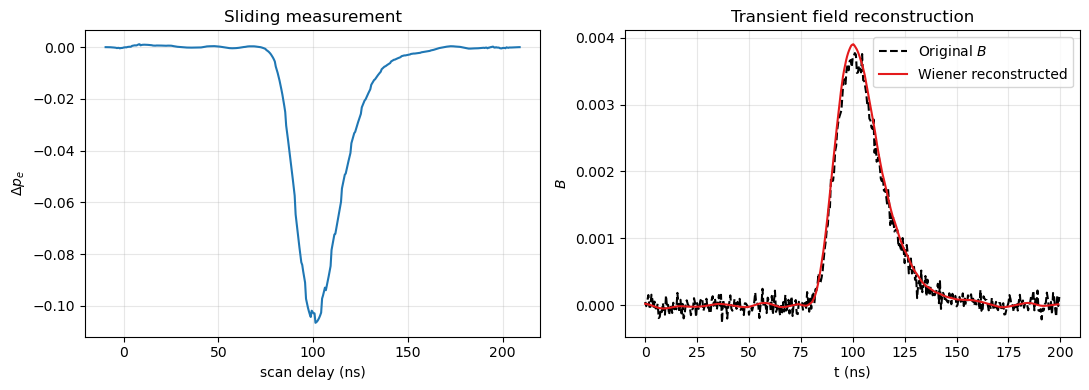

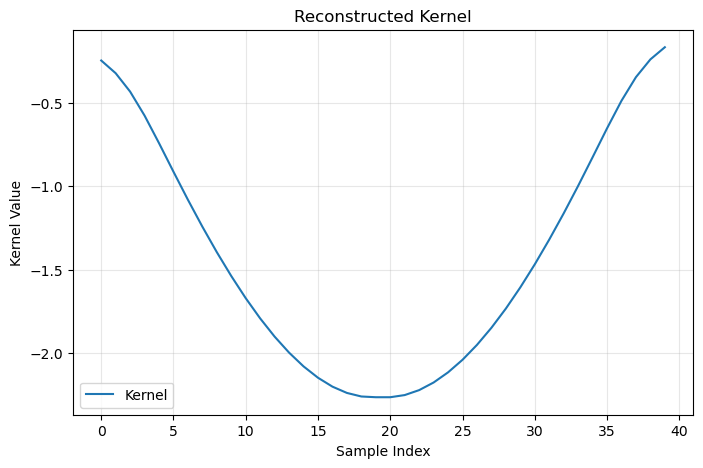

In [2]:
from sqc.experiments.transient import TransientSensingExperiment
from sqc.reconstruction.wiener import WienerReconstruction

qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.9553, n_levels=2,
)

# freq
print(f"qubit frequency: {qubit.frequency}")
print(f"Optimal work point flux: {qubit.optimal_work_point()}")
trans_exp = TransientSensingExperiment(qubit=qubit)
trans_result = trans_exp.run()
kernel = trans_result.data["kernel"]

rec = WienerReconstruction(lambda_reg=CONFIG.reconstruction.lambda_reg)
B_rec_signal = rec.reconstruct(trans_result, kernel=trans_result.data["kernel"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(trans_result.axes["scan"], trans_result.data["delta_p"], color="#1f77b4")
axes[0].set_xlabel("scan delay (ns)"); axes[0].set_ylabel(r"$\Delta p_e$")
axes[0].set_title("Sliding measurement"); axes[0].grid(alpha=0.3)

axes[1].plot(trans_result.axes["t_flux"], trans_result.data["flux_samples"], "k--", label="Original $B$")
axes[1].plot(B_rec_signal.t_list, B_rec_signal.signal, color="#e41a1c", label="Wiener reconstructed")
axes[1].set_xlabel("t (ns)"); axes[1].set_ylabel("$B$")
axes[1].set_title("Transient field reconstruction"); axes[1].legend(); axes[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(len(kernel)), kernel, label="Kernel")
plt.xlabel("Sample Index")
plt.ylabel("Kernel Value")
plt.title("Reconstructed Kernel")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Cryoscope 完整 pipeline — 标定→测量→重建

两步 inversion 策略：
-  — 通过标定表  反查 $
-  — 通过 qubit 解析色散关系直接反演  = f_Q^{-1}(\Delta f)$

可选  对相位导数做 Savitzky-Golay 平滑（噪声数据）。

注意：
- 标定varphi的范围，np.unwrap 可能不够
- 检查IQ相位提取
- 标定波形必须在脉冲之后，不能覆盖，引入额外相位

freq=2.839 GHz, sensitivity=-6.752 GHz/Phi0
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.64571412-0.29575146j]
 [-0.12757191+0.68857428j]
 [ 0.07182256-0.00409143j]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.65741103-0.2685823j ]
 [-0.21289173+0.66725438j]
 [ 0.07075467+0.010806j  ]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.66810728-0.24057116j]
 [-0.29597923+0.63488938j]
 [ 0.06656411+0.02528182j]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.67773634-0.21175559j]
 [-0.37529888+0.59158056j]
 [ 0.05934426+0.03865846j]]
State at t=10.00 ns: Quantum object: dims=[[3], [1]], shape=(3, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.68622863-0.18215964j]
 [-0.44933212+0.53763066j]
 [ 0.04934656+0.050269j  ]]
State at t=10.00 ns: Quant

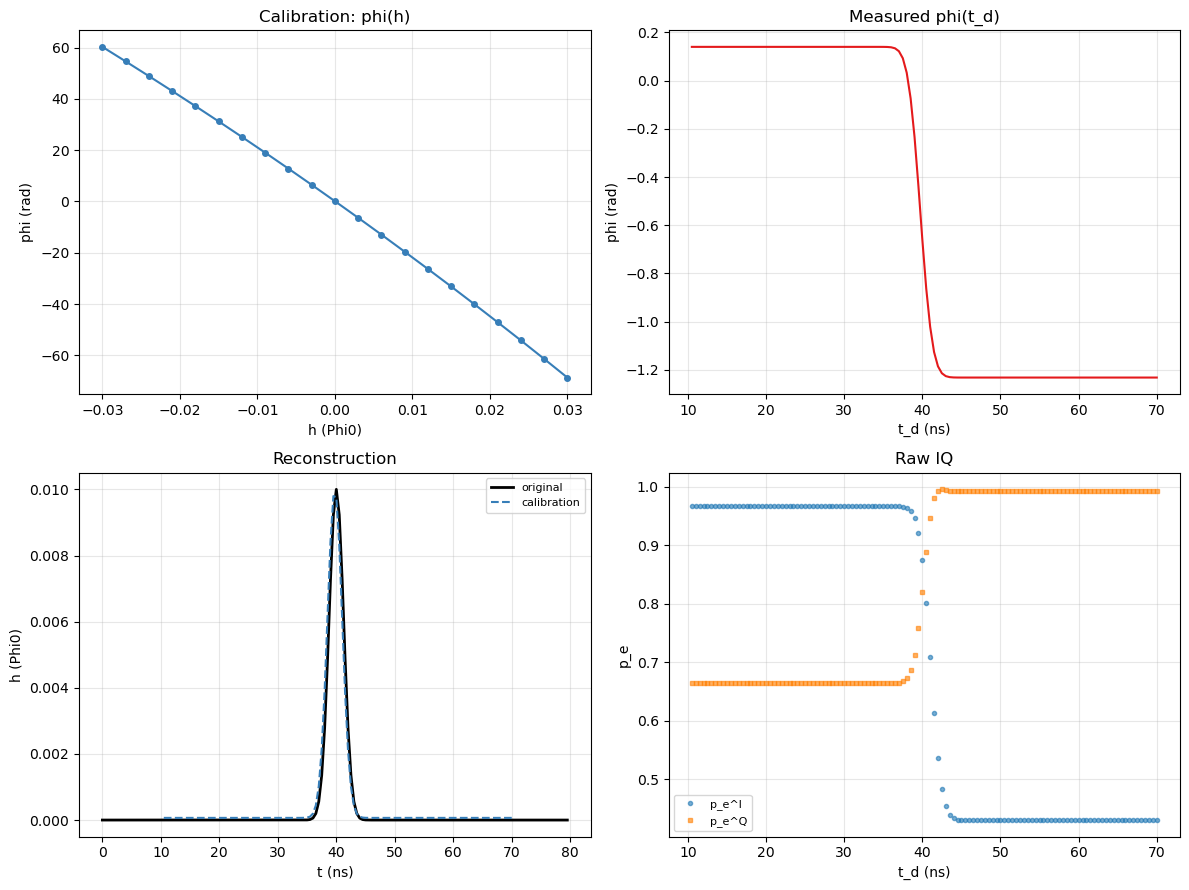

In [3]:
# === Cryoscope: 标定 → 测量 → 重建 ===
from sqc.calibration.flux_response import FluxResponseCalibration
from sqc.experiments.cryoscope import CryoscopeExperiment
from sqc.reconstruction.cryoscope import CryoscopeReconstruction

# ---- qubit（最优灵敏度工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=np.arctan(np.sqrt(2)) / np.pi,
    n_levels=3,
)
print(f"freq={qubit.frequency/(2*np.pi):.3f} GHz, sensitivity={qubit.frequency_sensitivity(qubit.flux)/(2*np.pi):.3f} GHz/Phi0")

# ---- Step 1: 标定 ----
h_list = np.linspace(-0.03, 0.03, 21)
cal = FluxResponseCalibration(qubit=qubit, method="cryoscope", h_list=h_list, tau=50.0)
cal_table = cal.calibrate()
print(f"cal: kind={cal_table.kind}, h in [{cal_table.inputs[0]:.3f},{cal_table.inputs[-1]:.3f}], phi in [{cal_table.outputs[0]:.3f},{cal_table.outputs[-1]:.3f}] rad")

# ---- Step 2: 测量 ----
test_signal = FluxSignal(type=3, t_list=CONFIG.pulse.make_time(0, 80), amplitude=0.01, center=40, width=5)
cryo_exp = CryoscopeExperiment(qubit=qubit, flux_signal=test_signal, tau=50.0)
meas = cryo_exp.run()

# ---- Step 3: 重建（两种 inversion 对比）----
recon_cal = CryoscopeReconstruction(calibration=cal_table, tau=50.0, inversion="calibration")
recon_resp = CryoscopeReconstruction(qubit=qubit, tau=50.0, inversion="response")
h_cal = recon_cal.reconstruct(meas)
h_resp = recon_resp.reconstruct(meas)

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes[0,0].plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", ms=4)
axes[0,0].set(xlabel="h (Phi0)", ylabel="phi (rad)", title="Calibration: phi(h)"); axes[0,0].grid(alpha=0.3)

trunc_inc = meas.axes["trunc"][::-1]  # axis stored decreasing
axes[0,1].plot(trunc_inc, meas.data["varphi"], color="#e41a1c")
axes[0,1].set(xlabel="t_d (ns)", ylabel="phi (rad)", title="Measured phi(t_d)"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(test_signal.t_list, test_signal.signal, "k-", lw=2, label="original")
axes[1,0].plot(h_cal.t_list, h_cal.signal, "--", color="#377eb8", label="calibration")
#axes[1,0].plot(h_resp.t_list, h_resp.signal, "-.", color="#4daf4a", label="response")
axes[1,0].set(xlabel="t (ns)", ylabel="h (Phi0)", title="Reconstruction"); axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(trunc_inc, meas.data["p_e_I"], "o", color="#1f77b4", ms=3, alpha=0.6, label="p_e^I")
axes[1,1].plot(trunc_inc, meas.data["p_e_Q"], "s", color="#ff7f00", ms=3, alpha=0.6, label="p_e^Q")
axes[1,1].set(xlabel="t_d (ns)", ylabel="p_e", title="Raw IQ"); axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)
fig.tight_layout(); plt.show()


## 6. 重构新增能力速览

下面这些模块在 `src/` 中不存在，是重构后新增的能力。详见 [`docs/architecture.md`](docs/architecture.md)。

### 6.1 全局配置 `sqc.config.CONFIG`
层级化配置：`awg` → `pulse` → `simulation` → `reconstruction`。所有时间轴从 `awg.dt` 派生。

### 6.2 标定层 `sqc.calibration.*`
- `FluxResponseCalibration` — Φ ↔ ω 标定曲线
- `QubitFrequencyCalibration` — 频率扫描标定
- `Predistortion` — Z-line 预失真补偿
- `TransferFunctionFit` — 传输函数辨识

### 6.3 重建算法目录 `sqc.reconstruction.*`
- `WienerReconstruction`（线性反卷积）
- `HammersteinReconstruction`（非线性块模型）
- `NumericalInverseReconstruction`（LM 优化，多基函数）
- `RamseyIQReconstruction` / `RamseyUnwrapReconstruction` / `DiffEchoReconstruction` / `CryoscopeReconstruction`

### 6.4 端到端工作流 `sqc.workflows.*`
- `ZCrosstalkWorkflow` — 双比特 Z-line 串扰提取与补偿端到端演示

下面给出 `ZCrosstalkWorkflow` 的最小调用框架（**不实际运行**，因为需要构造完整 `ChipTopology` + `TransferMatrix`）：

In [ ]:
# 演示 import — 实际运行参考 sqc/workflows/z_crosstalk.py 顶部 docstring
from sqc.workflows.z_crosstalk import ZCrosstalkWorkflow
from sqc.devices.chip import ChipTopology
from sqc.hardware.transfer_matrix import TransferMatrix
from sqc.control.waveform import Waveform

print("ZCrosstalkWorkflow 字段:")
for f in ZCrosstalkWorkflow.__dataclass_fields__:
    print(f"  - {f}")
print("\n要跑通需要：ChipTopology(QA, QB) + flux_pulse_on_A: Waveform + true_transfer_matrix: TransferMatrix")
print("详见 tests/regression/test_z_crosstalk_baseline.py 的完整 fixture 构造。")

## 7. Delay Ramsey — `DelayRamseyExperiment` + `DelayRamseyCalibration` + `TailReconstruction`

**新增协议**（Track B 1.3）。在磁通敏感点处，通过滑动短 Ramsey 序列测量方波脉冲拖尾。

对应 `_sensing theory.md` §delay Ramsey。

**流程**：
1. **测量** — 施加方波 + 拖尾，在延迟 $t_d$ 处运行短 Ramsey（$\tau_R$），IQ 读相 → $\varphi(t_d)$
2. **基线** — 零磁通下重复，得到 $\varphi_{base}$，相减得 $\varphi_{tail}(t_d)$
3. **标定** — 扫描已知 $z$（flux高度），建立 $\varphi_{cal}(z) = \tau_R \cdot \kappa \cdot z$，拟合斜率 $k$
4. **重建** — $\Phi_{tail}(t_d) = \varphi_{tail}(t_d) / k$

**与 Cryoscope 对比**：Cryoscope 在甜点工作（截断瞬态抑制好但灵敏度低），Delay Ramsey 在敏感点工作（灵敏度高，适合小信号拖尾测量）。

f_q = 3.164 GHz
--- Calibration (diagnostic) ---
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70594028-0.04136832j]
 [-0.69581348+0.1256208j ]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70604666-0.03937121j]
 [-0.69687908+0.11961421j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70615436-0.03736756j]
 [-0.69788989+0.11357546j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.7062517-0.03535549j]
 [-0.6988569+0.10750607j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70634763-0.03333059j]
 [-0.69977316+0.10138846j]]
State at t=10.00 ns: Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[ 0.70643894-0.03130565j]
 [-0.70063453+0.09526404j]]

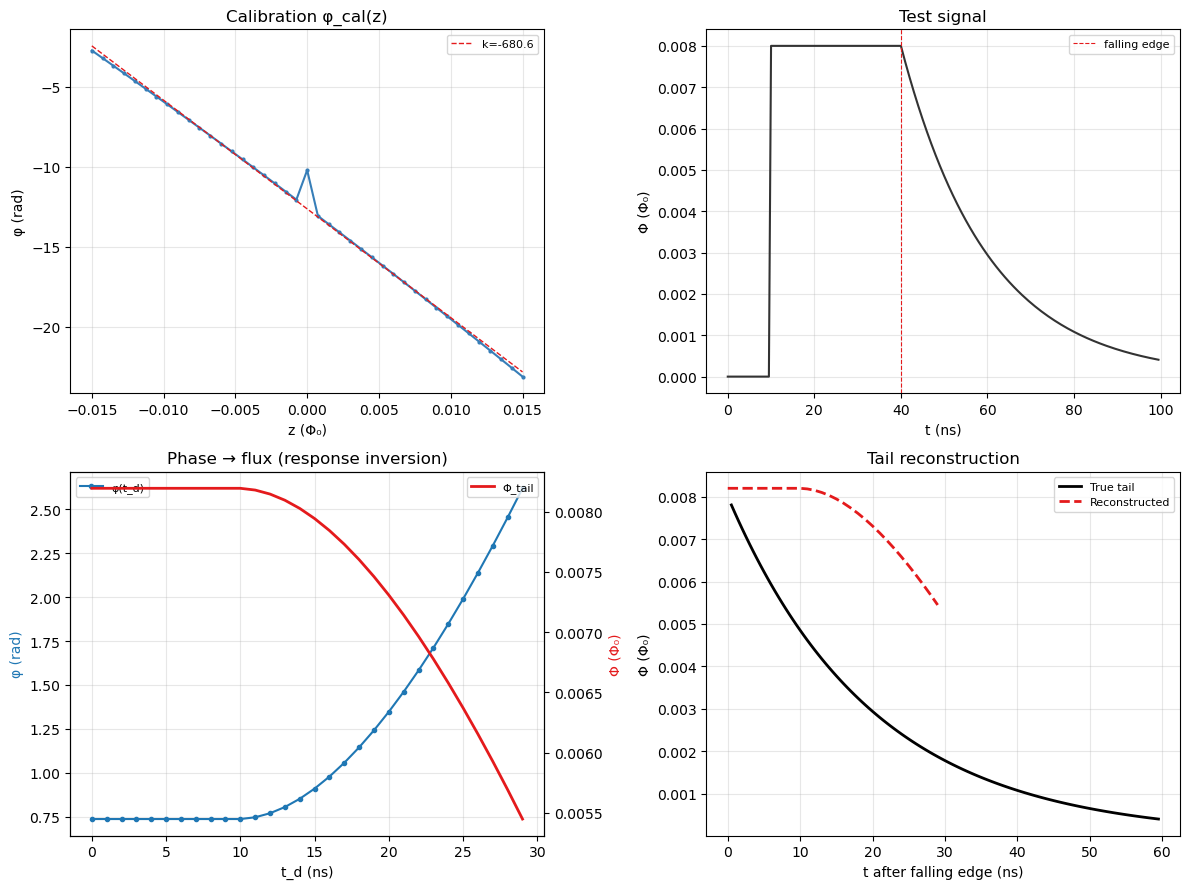

RMSE = 0.003494 Φ₀


In [2]:
# === Delay Ramsey: measurement + response inversion ===
# 解析反演: φ(t_d) → Δω=φ/τ_R → Φ=f_Q⁻¹(f_q+Δω) → 直接得到 Φ_avg(t_d)
from sqc.experiments.delay_ramsey import DelayRamseyExperiment
from sqc.calibration.delay_ramsey import DelayRamseyCalibration
from sqc.reconstruction.tail import TailReconstruction

# ---- 初始化 qubit（磁通敏感工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.25,
    n_levels=2,
)
print(f"f_q = {qubit.frequency/(2*np.pi):.3f} GHz")

# ---- 测试信号：方波 + 指数拖尾 ----
t_list = CONFIG.pulse.make_time(0, 100)
test_signal_arr = np.zeros(len(t_list))
test_signal_arr[(t_list >= 10) & (t_list <= 40)] = 0.008
tail_mask = t_list > 40
test_signal_arr[tail_mask] = 0.008 * np.exp(-(t_list[tail_mask] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=test_signal_arr)

# ---- Step 1: 标定 (diagnostic, 验证 k = dφ/dz) ----
print("--- Calibration (diagnostic) ---")
z_list = np.linspace(-0.015, 0.015, 41)  # 密采样避免 unwrap 失败
cal = DelayRamseyCalibration(qubit=qubit, z_list=z_list, tau_R=20.0,
                             t_rabi=np.linspace(0, 10, 20))
cal_table = cal.calibrate()
k = cal_table.fit_params["k"]
print(f"k = {k:.1f} rad/Φ₀ (expected ≈ -680)")

# ---- Step 2: 测量 — 滑动短 Ramsey 扫拖尾 ----
print("--- Delay Ramsey measurement ---")
t_d_list = CONFIG.pulse.make_time(0, 80)[::2][:30]
dr_exp = DelayRamseyExperiment(qubit=qubit, flux_signal=test_flux,
                               t_d_list=t_d_list, tau_R=20.0,
                               t_rabi=np.linspace(0, 10, 20))
meas = dr_exp.run()

# ---- Step 3: 重建 — response inversion (解析色散反演) ----
print("--- Reconstruction (response inversion) ---")
recon = TailReconstruction(method="delay_ramsey", inversion="response", qubit=qubit)
tail_flux = recon.reconstruct(meas)

# ---- 可视化 ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# (a) 标定曲线 φ_cal(z)
ax = axes[0, 0]
ax.plot(cal_table.inputs, cal_table.outputs, "o-", color="#377eb8", markersize=2)
ax.plot(z_list, k * z_list + cal_table.fit_params["intercept"],
        "--", color="#e41a1c", lw=1, label=f"k={k:.1f}")
ax.set(xlabel="z (Φ₀)", ylabel="φ (rad)", title="Calibration φ_cal(z)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (b) 原始信号
ax = axes[0, 1]
ax.plot(test_flux.t_list, test_flux.signal, color="#333333", lw=1.5)
ax.axvline(x=40, color="#e41a1c", ls="--", lw=0.8, label="falling edge")
ax.set(xlabel="t (ns)", ylabel="Φ (Φ₀)", title="Test signal")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) 测量相位 + 重建拖尾
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(meas.axes["t_d"], meas.data["varphi"], "o-", color="#1f77b4", ms=3, label="φ(t_d)")
ax.set_xlabel("t_d (ns)"); ax.set_ylabel("φ (rad)", color="#1f77b4")
ax2.plot(tail_flux.t_list, tail_flux.signal, color="#e41a1c", lw=2, label="Φ_tail")
ax2.set_ylabel("Φ (Φ₀)", color="#e41a1c")
ax.legend(loc="upper left", fontsize=8); ax2.legend(loc="upper right", fontsize=8)
ax.set_title("Phase → flux (response inversion)"); ax.grid(alpha=0.3)

# (d) 重建 vs 真实拖尾
ax = axes[1, 1]
true_tail = test_signal_arr[t_list > 40]
true_tail_t = t_list[t_list > 40] - 40
ax.plot(true_tail_t, true_tail, "k-", lw=2, label="True tail")
ax.plot(tail_flux.t_list, tail_flux.signal, "--", color="#e41a1c", lw=2, label="Reconstructed")
ax.set(xlabel="t after falling edge (ns)", ylabel="Φ (Φ₀)", title="Tail reconstruction")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

# ---- 定量 ----
from scipy.interpolate import interp1d
f_true = interp1d(true_tail_t, true_tail, kind="linear", fill_value="extrapolate")
rmse = np.sqrt(np.mean((tail_flux.signal - f_true(tail_flux.t_list))**2))
print(f"RMSE = {rmse:.6f} Φ₀")


## 8. $\pi$ 脉冲补偿法 — `PiPulseCompensationExperiment` + `TailReconstruction`

**新增协议**（Track B 1.4）。在磁通敏感点，用补偿脉冲 + π 脉冲的 2D 扫描测量方波拖尾。

对应 `_sensing theory.md` §$\pi$脉冲补偿法。

**流程**：
1. 施加方波，关断后存在拖尾 $\tilde{\Phi}_{sq}(t)$
2. 在延迟 $\tau$ 处施加补偿方波（宽 $T_\pi$，高 $z$）+ 同时施加 $\pi$ 脉冲
3. 若 $z$ 恰好抵消拖尾 → qubit 共振 → $P_e \to 1$
4. 2D 扫描 $(\tau, z)$ → 提取 $z^*(\tau) = \arg\max_z P_e(\tau, z)$
5. 拖尾波形 $\Phi_{tail}(\tau) \approx -z^*(\tau)$

**与 delay Ramsey 对比**：π 脉冲补偿是 2D 扫描（慢但直观），delay Ramsey 是 1D 扫描（快但需标定）。两者都在磁通敏感点工作，互补用于预失真验证。

f_q = 3.164 GHz
--- Pi-pulse compensation 2D scan ---


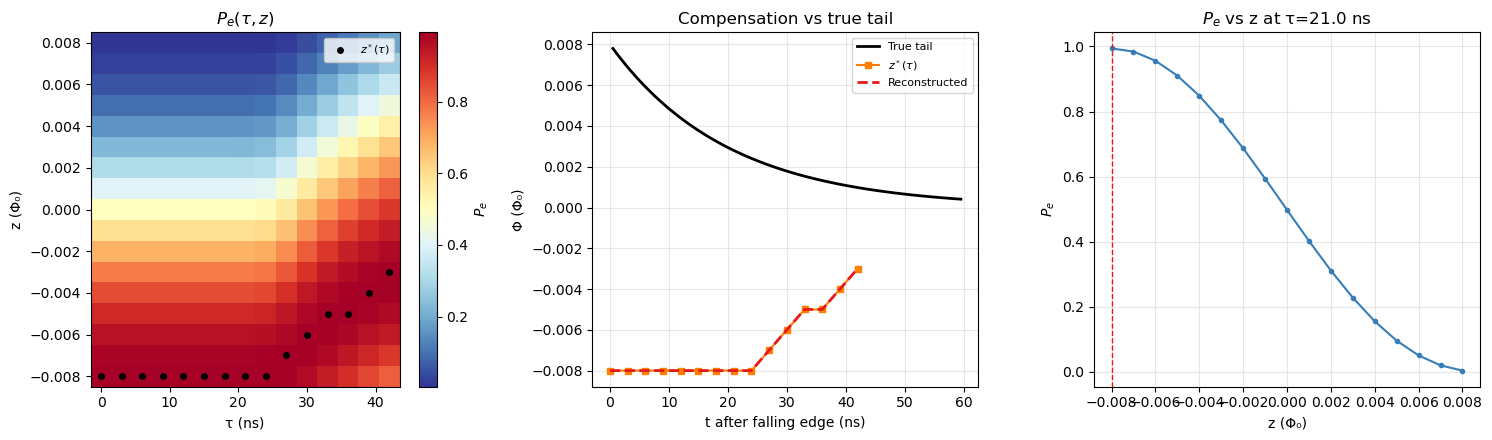

z* vs true tail RMSE = 0.010816 Φ₀


In [3]:
# === π 脉冲补偿法：2D 扫描 → 拖尾重建 ===
from sqc.experiments.pi_pulse_comp import PiPulseCompensationExperiment
from sqc.reconstruction.tail import TailReconstruction

# ---- 初始化 qubit（磁通敏感工作点）----
qubit = TransmonQubit(
    EC=0.2 * 2 * np.pi, EJ=10.0 * 2 * np.pi,
    T1=100.0e3, T2=50.0e3,
    flux=0.25, n_levels=2,
)
omega_bias = qubit.frequency
print(f"f_q = {omega_bias/(2*np.pi):.3f} GHz")

# ---- 测试信号（与 §7 相同）----
t_list = CONFIG.pulse.make_time(0, 100)
test_signal_arr = np.zeros(len(t_list))
test_signal_arr[(t_list >= 10) & (t_list <= 40)] = 0.008
tail_mask = t_list > 40
test_signal_arr[tail_mask] = 0.008 * np.exp(-(t_list[tail_mask] - 40) / 20)
test_flux = FluxSignal(type=8, t_list=t_list, signal=test_signal_arr)

# ---- 2D 扫描 (τ, z) ----
print("--- Pi-pulse compensation 2D scan ---")
tau_list = np.arange(0, 60, 3.0)[:15]        # 15 个延迟点
z_list = np.linspace(-0.008, 0.008, 17)      # 正负补偿高度

ppc_exp = PiPulseCompensationExperiment(
    qubit=qubit, flux_signal=test_flux,
    tau_list=tau_list, z_list=z_list,
    T_pi=10.0, omega_bias=omega_bias,
    t_rabi=np.linspace(0, 10, 20),
)
result = ppc_exp.run()

# ---- 重建 ----
recon = TailReconstruction(method="pi_pulse_comp")
tail_flux = recon.reconstruct(result)

# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) 2D P_e(τ, z) 热力图
ax = axes[0]
T, Z = np.meshgrid(result.axes["tau"], result.axes["z"], indexing="ij")
im = ax.pcolormesh(T, Z, result.data["p_e"], cmap="RdYlBu_r", shading="auto")
ax.plot(result.axes["tau"], result.data["z_star"], "ko", markersize=4, label="$z^*(\\tau)$")
ax.set(xlabel="τ (ns)", ylabel="z (Φ₀)", title="$P_e(\\tau, z)$")
plt.colorbar(im, ax=ax, label="$P_e$")
ax.legend(fontsize=8)

# (b) z*(τ) vs 真实拖尾
ax = axes[1]
true_tail = test_signal_arr[t_list > 40]
true_tail_t = t_list[t_list > 40] - 40
ax.plot(true_tail_t, true_tail, "k-", lw=2, label="True tail")
ax.plot(result.axes["tau"], result.data["z_star"], "s-", color="#ff7f00", ms=4, label="$z^*(\\tau)$")
ax.plot(tail_flux.t_list, -tail_flux.signal, "--", color="#e41a1c", lw=2, label="Reconstructed")
ax.set(xlabel="t after falling edge (ns)", ylabel="Φ (Φ₀)", title="Compensation vs true tail")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (c) 某个 τ 的 P_e(z) 截面
ax = axes[2]
mid_idx = len(tau_list) // 2
ax.plot(z_list, result.data["p_e"][mid_idx], "o-", color="#377eb8", markersize=3)
ax.axvline(x=result.data["z_star"][mid_idx], color="#e41a1c", ls="--", lw=1)
ax.set(xlabel="z (Φ₀)", ylabel="$P_e$", title=f"$P_e$ vs z at τ={tau_list[mid_idx]:.1f} ns")
ax.grid(alpha=0.3)

fig.tight_layout(); plt.show()

# ---- 定量 ----
from scipy.interpolate import interp1d
f_true = interp1d(true_tail_t, true_tail, kind="linear", fill_value="extrapolate")
rmse = np.sqrt(np.mean((result.data["z_star"] - f_true(result.axes["tau"]))**2))
print(f"z* vs true tail RMSE = {rmse:.6f} Φ₀")
